# Result Analysis

This notebook contains the analysis and visualization of voting prediction results.
Separated from the experiment running for better organization.

In [2]:
# Core imports
import os
import pandas as pd
import datetime
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from importlib import reload

# Local imports
import SoD_Utils
import Save_Utils
import Visualization_Utils
import VotingResult
import Models_Utils
import Data_Utils

In [15]:
# Configuration
LANGUAGE = SoD_Utils.LANGUAGE_CZ
temperature = 0

# Load original data for claimed results comparison
data_path = SoD_Utils.get_dataset_path(LANGUAGE)
df = pd.read_spss(data_path)

# Vectorized extraction without Python loop
claimed_votes = df[['Q21']].rename(columns={'Q21': 'voted_party'})
print(f"Loaded survey data: {len(claimed_votes)} respondents")

actual_results_df = Data_Utils.load_actual_results()
actual_results_country = actual_results_df[actual_results_df["region"]=="Česko"].iloc[0]
print(f"Loaded actual results: {actual_results_country}")

Loaded survey data: 3880 respondents
Loaded actual results: region                                               Česko
Voted                                               0.6543
Not Voted                                           0.3457
ANO 2011                                            0.2712
Koalice Spolu (ODS, TOP 09, KDU-ČSL)                0.2779
Koalice PIRÁTI a STAROSTOVÉ                         0.1562
Komunistická strana Čech a Moravy (KSČM)             0.036
Svoboda a přímá demokracie – Tomio Okamura (SPD)    0.0956
Česká strana sociálně demokratická (ČSSD)           0.0465
Trikolóra, Svobodní a Soukromníci                   0.0276
Přísaha Roberta Šlachty                             0.0468
Jiná strana                                         0.0422
Name: 0, dtype: object


In [4]:
# Load voting results from saved files
# Modify the model name and file path as needed
model = "gpt-4o"

# Load results
voting_results = pd.read_csv(f"results/voting_results_n=3880_t={temperature}_{model}.csv")

print(f"Loaded voting results: {len(voting_results)} respondents")
print(f"Model: {model}")
print(f"Temperature: {temperature}")

Loaded voting results: 3880 respondents
Model: gpt-4o
Temperature: 0


## Result Evaluation

Validate the quality of the voting results by checking for common issues.

In [ ]:
# Evaluate voting results quality
tol = 0.01
bad_voted_sum, bad_party_probs_sum, duplicate_parties = VotingResult.evaluate_voting_results(voting_results, tol)

# Print details
if bad_voted_sum:
    print(f"[WARN] {len(bad_voted_sum)} respondents where voted+not_voted != 1 (|delta|>{tol}):")
    for rid, v, nv, s in bad_voted_sum[:20]:
        print(f" - ID={rid}: voted={v:.3f}, not_voted={nv:.3f}, sum={s:.3f}")
    if len(bad_voted_sum) > 20:
        print(f" ... and {len(bad_voted_sum)-20} more")
else:
    print("[OK] All respondents have voted+not_voted summing to 1 within tolerance.")

if bad_party_probs_sum:
    print(f"[WARN] {len(bad_party_probs_sum)} respondents where party probabilities don't sum to 1 (|delta|>{tol}):")
    for rid, s, v in bad_party_probs_sum[:20]:
        print(f" - ID={rid}: voted={v}, prob_sum={s:.3f}")
    if len(bad_party_probs_sum) > 20:
        print(f" ... and {len(bad_party_probs_sum)-20} more")
else:
    print("[OK] All respondents have party probabilities summing to 1 within tolerance (when parties present).")

if duplicate_parties:
    print(f"[WARN] {len(duplicate_parties)} respondents with duplicate party names:")
    for rid, dups in duplicate_parties[:20]:
        print(f" - ID={rid}: duplicates={dups}")
    if len(duplicate_parties) > 20:
        print(f" ... and {len(duplicate_parties)-20} more")
else:
    print("[OK] No duplicate party names found in any respondent's parties list.")

In [ ]:
# Visualize party probability errors
if bad_party_probs_sum:
    Visualization_Utils.visualize_party_errors([abs(1-s) for _, s, _ in bad_party_probs_sum])
else:
    print("No party probability errors to visualize.")

## Visualization

Generate comprehensive visualizations comparing predicted vs actual results.

UFuncTypeError: ufunc 'greater' did not contain a loop with signature matching types (<class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.StrDType'>) -> None

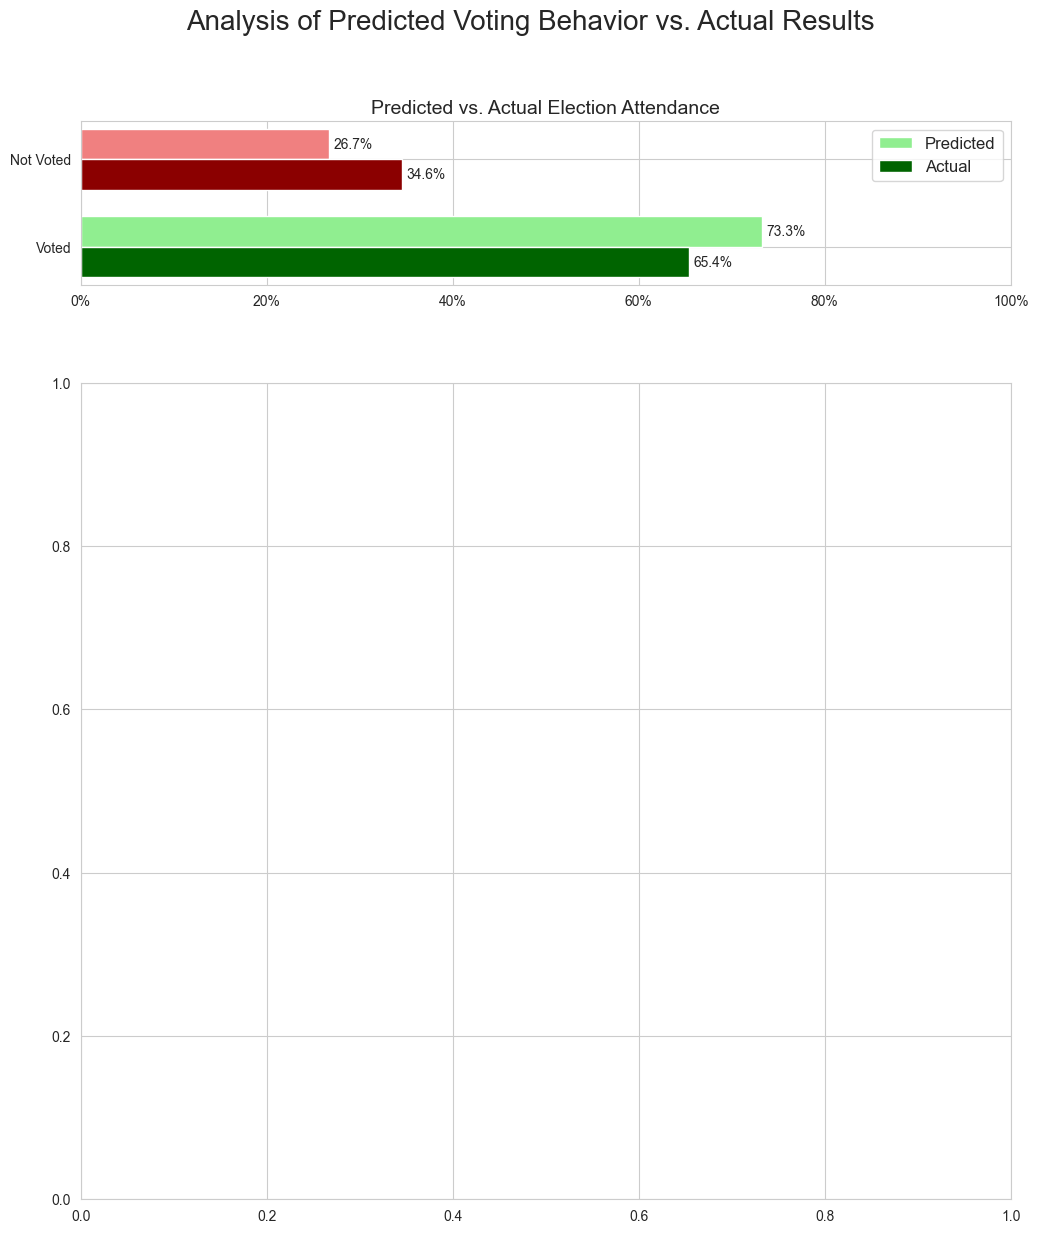

In [10]:
# Generate aggregated results and visualizations
predicted_series = Visualization_Utils.aggregate_columns(voting_results, True)

# Visualize the results
fig = Visualization_Utils.visualize_comprehensive_results(
    predicted_series,
    actual_results,
    model_name=None,
    actual_is_claimed=False
)

## Comparative Analysis

Compare multiple models and generate error analysis.

In [ ]:
# Compare current model with claimed and actual results
metric = 'RMSE'  # or 'MAE'

# Get claimed results from survey data
claimed_parties, claimed_attendance = SoD_Utils.get_actual_results(
    claimed_votes.iloc[list(voting_results.keys())]
)

# Generate comparison plots
# Update: evaluate_polls still expects party dicts; extract party portion from the series
claimed_series = pd.Series({**{Data.VOTED: claimed_attendance[Data.VOTED], Data.NOT_VOTED: claimed_attendance[Data.NOT_VOTED]}, **claimed_parties})
# Use only party parts for poll comparison
predicted_party_dist = {k: float(v) for k, v in predicted_series.items() if k not in (Data.VOTED, Data.NOT_VOTED)}
claimed_party_dist = {k: float(v) for k, v in claimed_series.items() if k not in (Data.VOTED, Data.NOT_VOTED)}
actual_party_dist = actual_parties
Visualization_Utils.evaluate_polls(predicted_party_dist, claimed_party_dist, actual_party_dist, metric, "Elections", model)
# Attendance comparison remains optional; evaluate_polls is for parties; skipping separate attendance heatmap

## Multi-Model Comparison

Compare results across different models.

In [ ]:
# List of model names to compare
model_names = [
    "gpt-4.1-nano",
    "gpt-4o-mini",
    "gpt-4.1",
    "gpt-4o"
]

# Load all model results
voting_results_list = []
for model_name in model_names:
    try:
        file_suffix = "_(uncertain_ID)" if model_name != "gpt-4o" else ""
        results = Save_Utils.load_results_from_json(
            f"results/voting_results_n=3880_t=0_{model_name}{"_(uncertain_ID)" if model_name!="gpt-4o" else ""}.json",
            VotingResult.VotingResult
        )
        voting_results_list.append(results)
        print(f"✓ Loaded {model_name}: {len(results)} respondents")
    except FileNotFoundError:
        print(f"✗ File not found for {model_name}")
        voting_results_list.append({})

print(f"\nSuccessfully loaded {len([r for r in voting_results_list if r])} model results.")

In [ ]:
# Generate and save comparison graphs
for model_name, voting_results_model in zip(model_names, voting_results_list):
    if not voting_results_model:  # Skip if no results loaded
        continue
        
    # Build DataFrame and aggregate to a single series
    df_pred = Save_Utils.results_to_dataframe(voting_results_model)
    predicted_series = Visualization_Utils.aggregate_columns(df_pred, True)
    
    reload(Visualization_Utils)
    # Visualize the results
    actual_series = pd.Series({**{Data.VOTED: actual_attendance[Data.VOTED], Data.NOT_VOTED: actual_attendance[Data.NOT_VOTED]}, **actual_parties})
    fig = Visualization_Utils.visualize_comprehensive_results(
        predicted_series,
        actual_series,
        model_name=model_name,
        actual_is_claimed=False
    )
    # Save the plot as a PNG file
    if fig:
        fig.savefig(f"graphs/{model_name}.png")
        print(f"Saved graph for {model_name}")

In [ ]:
# Generate error comparison for all models
# metric = 'RMSE'  # or 'MAE'
metric = 'MAE'

reload(Visualization_Utils)
for model_name, voting_results_model in zip(model_names, voting_results_list):
        
    df_pred = Save_Utils.results_to_dataframe(voting_results_model)
    predicted_series = Visualization_Utils.aggregate_columns(df_pred, True)
    claimed_parties, claimed_attendance = SoD_Utils.get_actual_results(claimed_votes, False)
    predicted_party_dist = {k: float(v) for k, v in predicted_series.items() if k not in (Data.VOTED, Data.NOT_VOTED)}
    fig = Visualization_Utils.evaluate_polls(predicted_party_dist, claimed_parties, actual_parties, metric, "Elections Results", model_name)
    if fig:
        fig.savefig(f"graphs/{metric}_{model_name}.png")
        print(f"Saved graph for {model_name}")
    # Visualization_Utils.evaluate_polls(predicted_attendance, claimed_attendance, actual_attendance, metric, "Elections Attendance", model_name, 15)

## Region Analysis

In [52]:
model = "gpt-4.1-nano"
# model = "gpt-4o-mini"
# model = "gpt-4.1"
# model = "gpt-4o"

temperature = 0
voting_results = pd.read_csv(f"results/voting_results_n=3880_t={temperature}_{model}.csv")

region_indices = df.groupby('KRAJ', observed=True).groups

Saved regional MAE CSV to: results/regional_pairwise_mae_t=0_gpt-4.1-nano.csv


,region,Predicted vs Actual,Predicted vs Claimed,Actual vs Claimed
0,Česko,0.028,0.036,0.014
1,Hlavní město Praha,0.046,0.054,0.023
2,Středočeský kraj,0.034,0.050,0.023
3,Jihočeský kraj,0.028,0.034,0.018
4,Plzeňský kraj,0.029,0.036,0.027
5,Karlovarský kraj,0.043,0.049,0.040
6,Ústecký kraj,0.048,0.053,0.013
7,Liberecký kraj,0.039,0.052,0.021
8,Královéhradecký kraj,0.029,0.046,0.038
9,Pardubický kraj,0.026,0.030,0.033


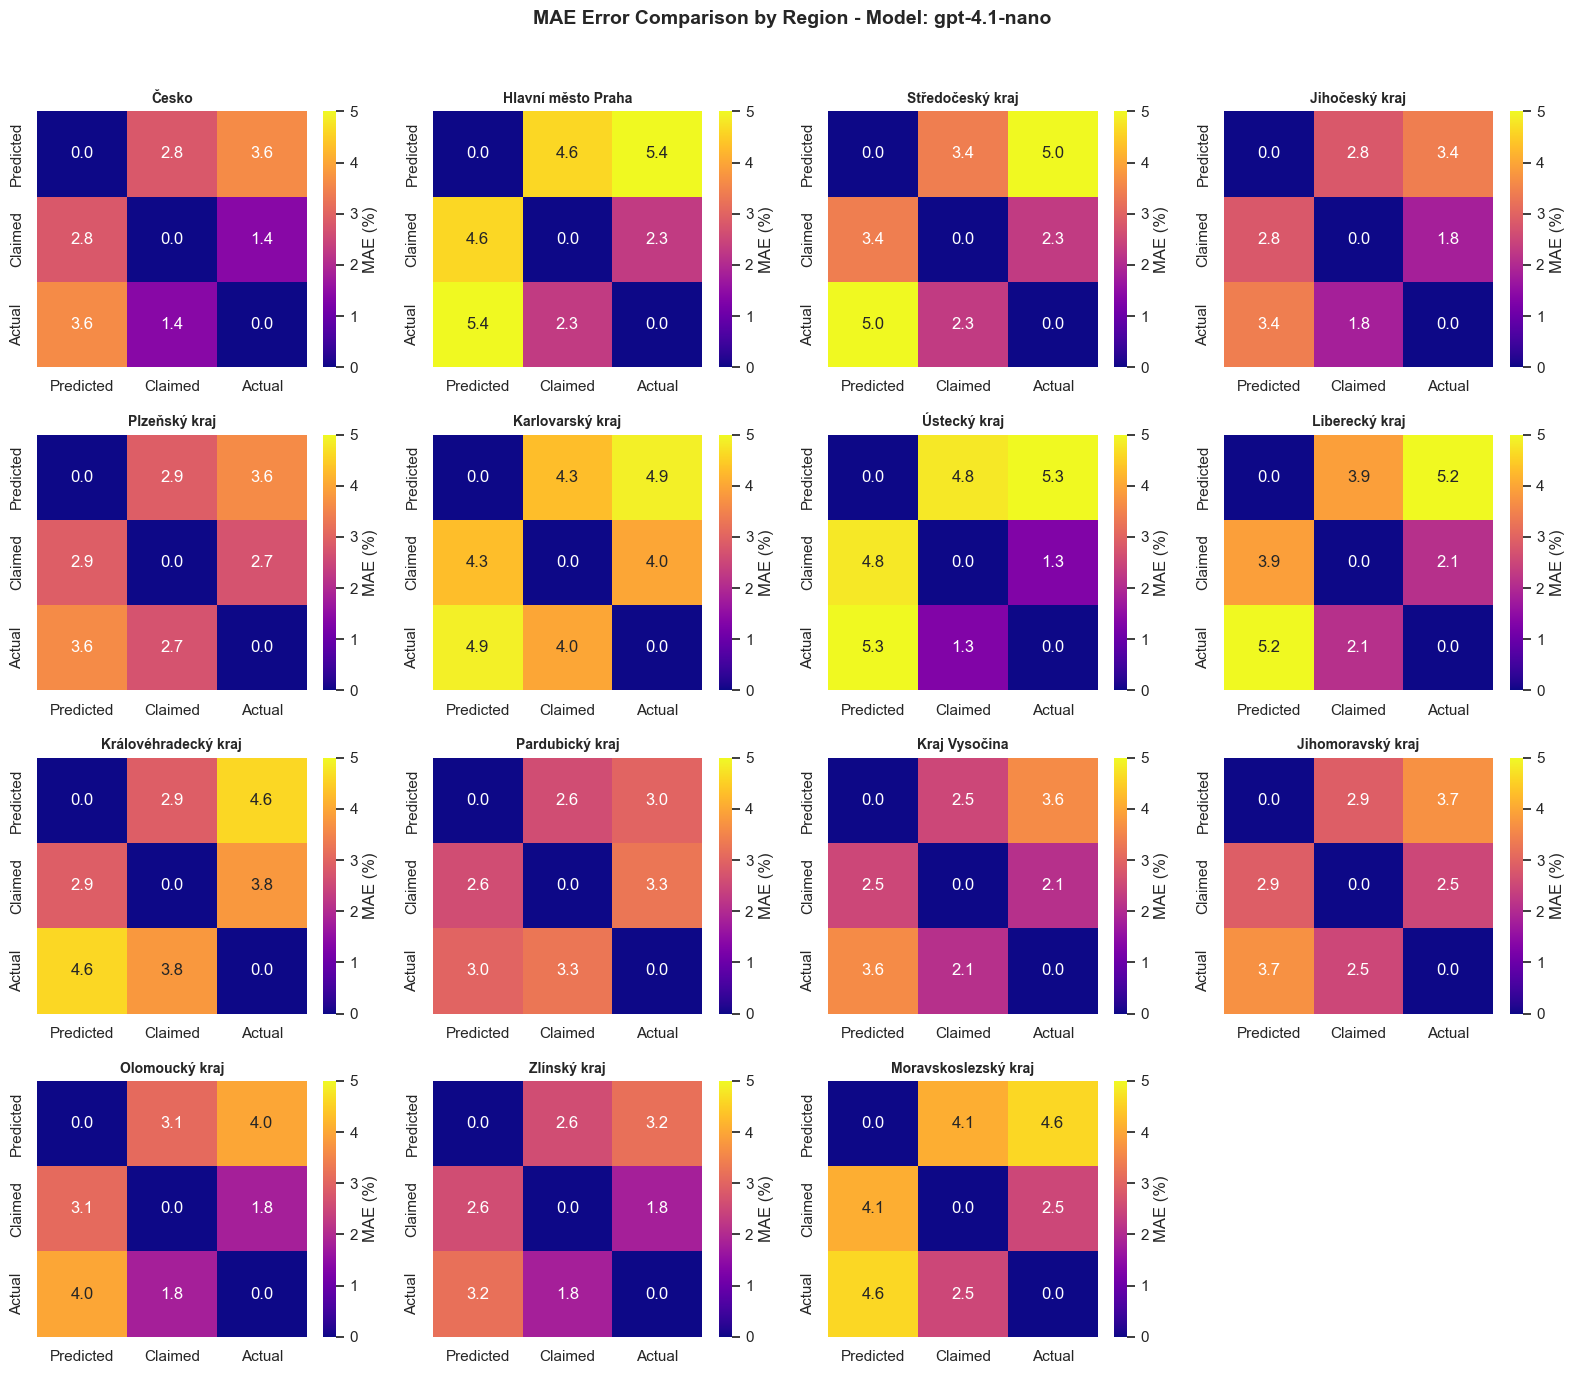

In [53]:
# Generate aggregated results and visualizations
from sklearn.metrics import mean_absolute_error

reload(Data_Utils)

rows = []

for idx, actual_results_region in actual_results_df.iterrows():
    region = actual_results_region["region"]
    if region == 'Česko':
        claimed_votes_region = claimed_votes
        predicted_votes_region = voting_results
    else:
        claimed_votes_region = claimed_votes.iloc[region_indices[region]]
        predicted_votes_region = voting_results.iloc[region_indices[region]]

    claimed_results_region = SoD_Utils.get_actual_results(claimed_votes_region)
    predicted_results_region = Data_Utils.aggregate_results_from_df(predicted_votes_region)

    actual_results_region = actual_results_region[Data_Utils.PARTY_COLUMNS_2021]
    predicted_results_region = predicted_results_region[Data_Utils.PARTY_COLUMNS_2021]
    claimed_results_region = claimed_results_region[Data_Utils.PARTY_COLUMNS_2021]

    mae_pred_vs_clmd = mean_absolute_error(predicted_results_region, claimed_results_region)
    mae_pred_vs_actu = mean_absolute_error(predicted_results_region, actual_results_region)
    mae_actu_vs_clmd = mean_absolute_error(actual_results_region, claimed_results_region)

    rows.append({
        "region": region,
        "Predicted vs Actual": round(mae_pred_vs_actu, 3),
        "Predicted vs Claimed": round(mae_pred_vs_clmd, 3),
        "Actual vs Claimed": round(mae_actu_vs_clmd, 3),
    })

regional_mae_df = pd.DataFrame(rows, columns=[
    "region",
    "Predicted vs Actual",
    "Predicted vs Claimed",
    "Actual vs Claimed",
])

# Ensure results directory exists
os.makedirs("results", exist_ok=True)
# Construct filename with model and temperature for traceability
csv_path = f"results/regional_pairwise_mae_t={temperature}_{model}.csv"
regional_mae_df.to_csv(csv_path, index=False)
print(f"Saved regional MAE CSV to: {csv_path}")

fig = Visualization_Utils.visualize_region_errors(regional_mae_df, title=f"MAE Error Comparison by Region - Model: {model}")
fig.savefig(f"graphs/regional_mae_{model}.png")
regional_mae_df